# Module 32 — Multi-Agent & Swarm: From Concept to KIMI K2.5

**Part VIII · Agents & Evaluation · 40–50 min**

---

One agent is easy. Two agents is organizational behavior.

In Module 31 we built an agent: a single LLM running in a while loop, calling tools, keeping state. That loop is a solved problem. You can write it in 80 lines and ship it.

The moment you add a second agent, nothing is a solved problem anymore. Who owns the state? Who decides when to stop? If A hands off to B and B gets stuck, who retries? If A and B write to the same file, who wins? If A asks B a question, is B a tool or a peer? These are not AI questions. These are **distributed systems** questions dressed in an LLM costume, and every multi-agent framework is, under the hood, a particular set of answers.

This module has two halves.

**32a** walks through the four patterns that every multi-agent system is built from: **handoff**, **blackboard**, **agent-as-tool**, and **debate**. We'll simulate each one with deterministic mock agents so you can see the message flow without any LLM noise in the way.

**32b** tells the story of how the field went from *OpenAI Swarm* (October 2024 — a cute little function-handoff library that got deprecated five months later) to *KIMI K2.5 Agent Swarm* (January 2026 — a single model that dynamically spawns up to 100 sub-agents in parallel and beats GPT-5.2 on web-search benchmarks). The interesting part is not the architecture diagram. It's the **training recipe**: PARL, Parallel-Agent RL, which exists because without it the model learns to ignore all the parallel machinery and just run sequentially.

Then we're going to break the parallelism on purpose and watch the speedup evaporate, because the whole point of this curriculum is that when you break things you learn what they were doing.

Thesis for the module:

> **Multi-agent systems are not about agents. They're about topology and scheduling. The model is one component in a system that mostly isn't a model.**


## 0 · Setup

Stdlib + numpy + matplotlib + networkx. No LLM API calls. Every "agent" in this notebook is a Python function with canned responses — that's a feature, not a limitation. We're studying the *topology*, and topology is easier to see when the nodes are dumb.

In [1]:
import json
import time
import random
import math
from dataclasses import dataclass, field
from typing import Callable, Any
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

# Palette — same as Part I.
PALETTE = {
    "ink":    "#1a1a2e",
    "paper":  "#f7f3e9",
    "rose":   "#e63946",
    "amber":  "#f4a261",
    "teal":   "#2a9d8f",
    "indigo": "#3d5a80",
    "plum":   "#7b2cbf",
    "lime":   "#a8dadc",
}

plt.rcParams.update({
    "figure.facecolor": PALETTE["paper"],
    "axes.facecolor":   PALETTE["paper"],
    "axes.edgecolor":   PALETTE["ink"],
    "axes.labelcolor":  PALETTE["ink"],
    "xtick.color":      PALETTE["ink"],
    "ytick.color":      PALETTE["ink"],
    "text.color":       PALETTE["ink"],
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

random.seed(7)
np.random.seed(7)
print("ready")

ready


---

# Part 32a — Foundations: Four Multi-Agent Patterns

Every multi-agent system you've ever seen — AutoGen, CrewAI, LangGraph, OpenAI Swarm, KIMI K2.5 — is built out of these four patterns, usually more than one at once. Before we get to the fancy stuff, let's make sure each pattern is concrete in your head.

Here they are, drawn:

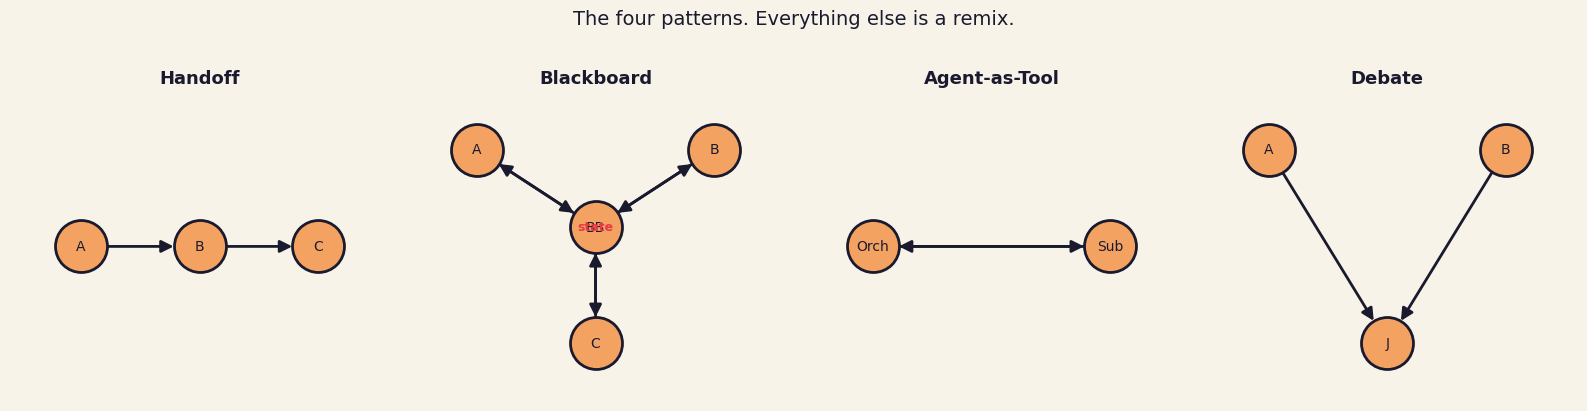

In [2]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
titles = ["Handoff", "Blackboard", "Agent-as-Tool", "Debate"]

def draw_nodes(ax, nodes, edges, title, directed=True):
    G = nx.DiGraph() if directed else nx.Graph()
    for n, pos in nodes.items():
        G.add_node(n, pos=pos)
    for e in edges:
        G.add_edge(*e[:2], **(e[2] if len(e) > 2 else {}))
    pos = nx.get_node_attributes(G, "pos")
    nx.draw_networkx_nodes(G, pos, ax=ax,
                           node_color=PALETTE["amber"],
                           edgecolors=PALETTE["ink"], node_size=1400, linewidths=2)
    nx.draw_networkx_edges(G, pos, ax=ax, arrows=directed,
                           edge_color=PALETTE["ink"], width=2,
                           arrowsize=18, node_size=1400)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=10, font_color=PALETTE["ink"])
    ax.set_title(title, color=PALETTE["ink"], fontsize=13, fontweight="bold")
    ax.set_axis_off()
    ax.set_xlim(-0.3, 1.3); ax.set_ylim(-0.3, 1.3)

# Handoff: linear chain
draw_nodes(axes[0],
    {"A": (0.0, 0.5), "B": (0.5, 0.5), "C": (1.0, 0.5)},
    [("A","B"), ("B","C")], "Handoff")

# Blackboard: star-ish with shared memory in center
draw_nodes(axes[1],
    {"A": (0.0, 1.0), "B": (1.0, 1.0), "C": (0.5, 0.0), "BB": (0.5, 0.6)},
    [("A","BB"), ("BB","A"), ("B","BB"), ("BB","B"), ("C","BB"), ("BB","C")],
    "Blackboard")
axes[1].text(0.5, 0.6, "state", ha="center", va="center",
             fontsize=9, color=PALETTE["rose"], fontweight="bold")

# Agent-as-tool: orchestrator keeps control, calls sub
draw_nodes(axes[2],
    {"Orch": (0.0, 0.5), "Sub": (1.0, 0.5)},
    [("Orch","Sub"), ("Sub","Orch")], "Agent-as-Tool")

# Debate: two debaters + judge
draw_nodes(axes[3],
    {"A": (0.0, 1.0), "B": (1.0, 1.0), "J": (0.5, 0.0)},
    [("A","J"), ("B","J")], "Debate")

plt.suptitle("The four patterns. Everything else is a remix.",
             color=PALETTE["ink"], fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Four shapes, four scheduling disciplines:

| Pattern | Who holds control? | Communication | Failure mode |
|---|---|---|---|
| **Handoff** | Passed along the chain | Context + control transfer | Lost context at the boundary |
| **Blackboard** | Nobody / everybody | Shared mutable state | Race conditions |
| **Agent-as-tool** | Orchestrator keeps it | Call / return | Sub-agent takes forever |
| **Debate** | External judge | Parallel arguments → aggregator | Judge gets gamed |

Let's build each one.

## 1 · Handoff: Planner → Coder → Reviewer

The simplest multi-agent pattern. Agent A does its thing, then passes **the context and the control token** to agent B. B sees what A did, continues, hands off to C. No shared state besides the message that gets forwarded.

This is how OpenAI Swarm worked. It's also how a lot of production "agent pipelines" still work in 2026, because when you don't need parallelism, you really don't need parallelism. Linear is fine. Linear debugs.

We'll run a toy coding task through three agents:

1. **Planner** — reads the task, writes a one-line spec.
2. **Coder** — reads the spec, writes Python.
3. **Reviewer** — reads the code, flags bugs, optionally sends it back.

Each "agent" is a Python function with canned logic. No LLM. The point is the *protocol*, not the intelligence.

In [3]:
@dataclass
class Message:
    sender: str
    content: str
    meta: dict = field(default_factory=dict)

# ----- the three agents -----
def planner(task: str) -> Message:
    # canned: turn a task string into a spec string
    if "sum" in task and "even" in task:
        spec = "function sum_even(xs): return sum of even ints in xs"
    elif "reverse" in task:
        spec = "function reverse_string(s): return s reversed"
    else:
        spec = f"function solve(x): {task}"
    return Message(sender="planner", content=spec)

def coder(spec_msg: Message) -> Message:
    spec = spec_msg.content
    # canned code generation. Note: the sum_even version has a bug on purpose.
    if "sum_even" in spec:
        code = "def sum_even(xs):\n    return sum(x for x in xs if x % 2 == 1)"  # BUG: x%2==1 instead of ==0
    elif "reverse_string" in spec:
        code = "def reverse_string(s):\n    return s[::-1]"
    else:
        code = "def solve(x):\n    return x"
    return Message(sender="coder", content=code, meta={"spec": spec})

def reviewer(code_msg: Message) -> Message:
    code = code_msg.content
    spec = code_msg.meta.get("spec", "")
    # canned review: runs a dumb pattern match against the spec
    if "sum of even" in spec and "% 2 == 1" in code:
        return Message(sender="reviewer",
                       content="BUG: filter keeps odds, spec says evens. Fix '% 2 == 1' to '% 2 == 0'.",
                       meta={"approved": False, "original": code})
    return Message(sender="reviewer", content="LGTM.",
                   meta={"approved": True, "original": code})

# ----- the handoff harness -----
def run_handoff(task: str, verbose=True):
    trace = []
    m = planner(task);          trace.append(m)
    m = coder(m);               trace.append(m)
    m = reviewer(m);            trace.append(m)
    if verbose:
        for t in trace:
            print(f"[{t.sender:>8}] {t.content}")
    return trace

trace = run_handoff("write code to sum even numbers in a list")

[ planner] function sum_even(xs): return sum of even ints in xs
[   coder] def sum_even(xs):
    return sum(x for x in xs if x % 2 == 1)
[reviewer] BUG: filter keeps odds, spec says evens. Fix '% 2 == 1' to '% 2 == 0'.


Notice what just happened:

- **Every agent sees only the previous agent's output.** The planner never sees the code. The coder never sees the review. That's a deliberate constraint: the thing passed down the chain is the *interface* between stages, and if you widen it you're secretly reinventing the blackboard pattern.
- **The reviewer caught the bug** — but only because we hand-wrote a reviewer that knew what to look for. In a real system, the reviewer is another LLM call, and it misses bugs all the time. Handoff quality is bounded by the weakest agent in the chain.
- **There's no retry.** If the reviewer says "BUG", the pipeline just... stops. Let's fix that — by adding one line.

In [4]:
def run_handoff_with_retry(task, max_retries=2, verbose=True):
    trace = []
    spec_msg = planner(task); trace.append(spec_msg)
    for attempt in range(max_retries + 1):
        code_msg = coder(spec_msg); trace.append(code_msg)
        review   = reviewer(code_msg); trace.append(review)
        if review.meta["approved"]:
            break
        # feedback loop: rewrite the spec to include the reviewer's complaint
        spec_msg = Message(sender="planner",
                           content=spec_msg.content + " | FIX: " + review.content)
    if verbose:
        for t in trace:
            print(f"[{t.sender:>8}] {t.content}")
    return trace

# our mock coder is still going to produce the same buggy code, so we watch it loop
_ = run_handoff_with_retry("sum even numbers", max_retries=2)

[ planner] function sum_even(xs): return sum of even ints in xs
[   coder] def sum_even(xs):
    return sum(x for x in xs if x % 2 == 1)
[reviewer] BUG: filter keeps odds, spec says evens. Fix '% 2 == 1' to '% 2 == 0'.
[   coder] def sum_even(xs):
    return sum(x for x in xs if x % 2 == 1)
[reviewer] BUG: filter keeps odds, spec says evens. Fix '% 2 == 1' to '% 2 == 0'.
[   coder] def sum_even(xs):
    return sum(x for x in xs if x % 2 == 1)
[reviewer] BUG: filter keeps odds, spec says evens. Fix '% 2 == 1' to '% 2 == 0'.


The handoff pattern just became a handoff-*with-feedback* pattern, which is what every real pipeline actually is. The moment you add retry, you're one step away from reinventing the agent loop from Module 31 — except now each "step" is a whole sub-agent. Multi-agent systems are agents all the way down.

## 2 · Blackboard: shared state and the race condition nobody warned you about

Handoff passes the context. The blackboard pattern does the opposite: everyone reads and writes a shared piece of state, and the "conversation" is literally the state diff between turns. This pattern dates back to 1970s AI (Hearsay-II for speech recognition) and it's still alive because it maps naturally to how humans collaborate on a document.

The trap: if two agents try to edit the same part of the blackboard at the same time, one of them wins and the other's work is silently lost. This is not a theoretical problem. Every time you've seen "the agent seemed to forget what it just did" in a multi-agent trace, there's a decent chance the blackboard ate it.

We'll simulate three agents collaborating on a document. Each agent is responsible for one section, but they occasionally stomp on each other.

In [5]:
class Blackboard:
    def __init__(self):
        self.state = {"intro": "", "body": "", "conclusion": ""}
        self.log = []   # every read/write, in order

    def read(self, key, agent):
        self.log.append(("R", agent, key, self.state[key]))
        return self.state[key]

    def write(self, key, value, agent):
        self.log.append(("W", agent, key, value))
        self.state[key] = value

def intro_writer(bb, tick):
    # writes its own section
    bb.write("intro", f"Intro v{tick} by Alice", agent="alice")

def body_writer(bb, tick):
    # reads intro, writes body
    intro = bb.read("intro", agent="bob")
    bb.write("body", f"Body v{tick} by Bob (saw intro='{intro[:12]}...')", agent="bob")

def conclusion_writer(bb, tick):
    body = bb.read("body", agent="carol")
    bb.write("conclusion", f"Conclusion v{tick} by Carol (saw body='{body[:12]}...')", agent="carol")

# ------- disciplined run: each agent runs once, in order -------
bb = Blackboard()
for tick in range(1, 2):
    intro_writer(bb, tick)
    body_writer(bb, tick)
    conclusion_writer(bb, tick)

print("Disciplined blackboard:")
for k, v in bb.state.items():
    print(f"  {k:>10}: {v}")

Disciplined blackboard:
       intro: Intro v1 by Alice
        body: Body v1 by Bob (saw intro='Intro v1 by ...')
  conclusion: Conclusion v1 by Carol (saw body='Body v1 by B...')


That worked because we enforced an order. Now watch what happens when two agents decide to "improve" the intro at the same tick — a common thing to happen in a swarm where roles aren't rigidly assigned.

In [6]:
class AliceEditor:
    def act(self, bb, tick): bb.write("intro", f"Intro edited by Alice @ t={tick}", "alice")

class DaveEditor:
    def act(self, bb, tick): bb.write("intro", f"Intro rewritten by Dave @ t={tick}", "dave")

# both agents try to own `intro`. No coordination.
bb = Blackboard()
agents = [AliceEditor(), DaveEditor()]
for tick in range(3):
    random.shuffle(agents)  # whoever goes last wins
    for a in agents:
        a.act(bb, tick)

print("Final intro:", bb.state["intro"])
print()
print("Write log:")
for row in bb.log:
    if row[0] == "W":
        print(" ", row)

Final intro: Intro edited by Alice @ t=2

Write log:
  ('W', 'alice', 'intro', 'Intro edited by Alice @ t=0')
  ('W', 'dave', 'intro', 'Intro rewritten by Dave @ t=0')
  ('W', 'dave', 'intro', 'Intro rewritten by Dave @ t=1')
  ('W', 'alice', 'intro', 'Intro edited by Alice @ t=1')
  ('W', 'dave', 'intro', 'Intro rewritten by Dave @ t=2')
  ('W', 'alice', 'intro', 'Intro edited by Alice @ t=2')


That's the race condition. Whoever writes last wins; everyone else's work is silently gone. In our toy version the tick order is random, and if you rerun the cell enough times Alice and Dave will swap which one "owns" the final document. In a real swarm this shows up as nondeterminism that's almost impossible to reproduce in a bug report.

Standard fixes:

- **Locking** (mutex per key). Kills parallelism on contended keys.
- **Optimistic concurrency** (compare-and-swap with a version number). Lets you detect conflicts and retry — this is what Google Docs does.
- **Per-agent namespaces.** Each agent writes to its own key; a merge step combines them. This is what KIMI K2.5's result-aggregation stage does, and it's why it works.

The lesson: **shared mutable state between agents is the same problem as shared mutable state between threads**. It's a distributed systems problem. LLM fanciness does not save you.

## 3 · Agent-as-tool: when a sub-agent is just a function call

Handoff transfers control. Agent-as-tool does not. The orchestrator **stays in the driver's seat** and calls a sub-agent the way it would call a calculator — send an input, get an output, decide what to do with it.

Architecturally this is the simplest pattern to reason about: the orchestrator's control flow is linear and debuggable, and sub-agents are just functions with opaque internals. It's also the pattern that Anthropic's Claude Agent SDK and OpenAI's Agents SDK converged on after Swarm got deprecated — explicit "tool" registration where one of the tools is "call this other agent."

Demo: an **architect** agent decomposes a project, and for each sub-task it calls a **code-writer** agent as a subroutine.

In [7]:
def code_writer_agent(subtask: str) -> str:
    # canned per-subtask outputs
    table = {
        "define User class":         "class User:\n    def __init__(self, name): self.name = name",
        "define greet function":     "def greet(u): return f'hi {u.name}'",
        "write main":                "if __name__ == '__main__':\n    print(greet(User('world')))",
    }
    return table.get(subtask, f"# TODO: {subtask}")

def architect_agent(project: str):
    print(f"[architect] decomposing project: {project!r}")
    subtasks = ["define User class", "define greet function", "write main"]
    artifacts = {}
    for st in subtasks:
        print(f"[architect] calling code_writer({st!r})")
        artifacts[st] = code_writer_agent(st)   # <-- sub-agent as tool call
        print(f"[architect]  <- got {len(artifacts[st])} chars")
    # the architect is the one who assembles. It never hands off.
    full = "\n\n".join(artifacts.values())
    return full

source = architect_agent("tiny greeter CLI")
print()
print("--- assembled source ---")
print(source)

[architect] decomposing project: 'tiny greeter CLI'
[architect] calling code_writer('define User class')
[architect]  <- got 58 chars
[architect] calling code_writer('define greet function')
[architect]  <- got 35 chars
[architect] calling code_writer('write main')
[architect]  <- got 58 chars

--- assembled source ---
class User:
    def __init__(self, name): self.name = name

def greet(u): return f'hi {u.name}'

if __name__ == '__main__':
    print(greet(User('world')))


Key property: the architect could have replaced `code_writer_agent` with a calculator, a search tool, or another LLM — the control flow doesn't care. Whereas in **handoff**, swapping agent B for a non-agent tool *breaks the pattern*, because handoff assumes B is going to do more than return a value; B is going to decide what comes next.

Agent-as-tool is the right pattern when:

- You have a strong "main thread" of reasoning and want sub-agents to be narrow specialists.
- You need **deterministic orchestration** — the main agent controls the loop.
- Debuggability matters more than flexibility.

It's the wrong pattern when:

- The sub-task is open-ended and the sub-agent might need to call *back* to the orchestrator (you'll end up reinventing handoff anyway).
- You need actual parallelism — which is where Module 32b goes.

## 4 · Debate: two agents argue, a third decides

Last foundational pattern. This one has a reputation for being either brilliant or theatrical depending on the week.

The idea: instead of trusting one agent's answer, have two agents generate **independent answers**, then let a third agent (the "judge") pick between them. If the two debaters make uncorrelated errors, the judge can do better than either alone — this is the same logic as ensembling, dressed up as a conversation.

Does it work? Sometimes. It works best when:

1. The judge is better at *evaluating* than at *generating* (which is usually true — critiquing is easier than creating).
2. The two debaters have genuinely different priors or tool access.
3. The question has a verifiable answer the judge can check against.

It degenerates into theater when all three agents are the same model with the same prompt — then you're just paying 3× for one opinion.

Let's test it on a toy QA task where we *know* the ground truth and we can measure whether debate actually helps.

In [8]:
# toy QA task: 40 questions, each is a simple arithmetic word problem.
# Ground truth is known. We compare single-agent vs debate-then-judge.

def make_questions(n=40, seed=1):
    rng = random.Random(seed)
    qs = []
    for _ in range(n):
        a, b = rng.randint(2, 20), rng.randint(2, 20)
        op = rng.choice(["+", "*", "-"])
        ans = {"+": a+b, "*": a*b, "-": a-b}[op]
        qs.append((f"{a} {op} {b}", ans))
    return qs

questions = make_questions()

# Mock agent A: gets addition right 90%, other ops 50%
# Mock agent B: gets multiplication right 95%, other ops 55%
# Both are noisy but their errors are mostly uncorrelated.
def noisy_agent(bias_op, high, low, rng):
    def fn(q, ans):
        p = high if bias_op in q else low
        if rng.random() < p:
            return ans
        else:
            return ans + rng.choice([-3, -2, -1, 1, 2, 3])  # wrong-ish
    return fn

def judge(q, ans, answer_a, answer_b, rng):
    # the judge can sanity-check: it computes the answer independently (it's "better at checking")
    # but its check is also noisy: 85% accurate.
    if rng.random() < 0.85:
        correct = ans
    else:
        correct = ans + rng.choice([-2, -1, 1, 2])
    # pick whichever debater's answer is closer to the judge's own computation
    return answer_a if abs(answer_a - correct) <= abs(answer_b - correct) else answer_b

rng = random.Random(42)
agent_a = noisy_agent("+", 0.90, 0.50, rng)
agent_b = noisy_agent("*", 0.95, 0.55, rng)

single_a = sum(1 for q, a in questions if agent_a(q, a) == a) / len(questions)
single_b = sum(1 for q, a in questions if agent_b(q, a) == a) / len(questions)

debate_correct = 0
for q, a in questions:
    aa = agent_a(q, a)
    bb = agent_b(q, a)
    picked = judge(q, a, aa, bb, rng)
    if picked == a:
        debate_correct += 1
debate_acc = debate_correct / len(questions)

print(f"Single agent A:         {single_a:.2%}")
print(f"Single agent B:         {single_b:.2%}")
print(f"Debate (A vs B, judge): {debate_acc:.2%}")

Single agent A:         60.00%
Single agent B:         72.50%
Debate (A vs B, judge): 82.50%


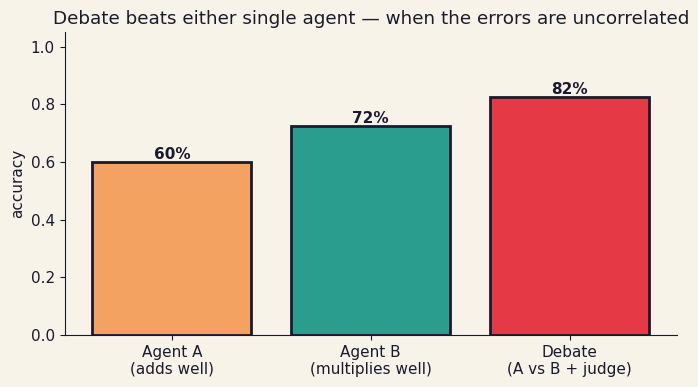

In [9]:
# Plot it
fig, ax = plt.subplots(figsize=(7, 4))
labels = ["Agent A\n(adds well)", "Agent B\n(multiplies well)", "Debate\n(A vs B + judge)"]
vals = [single_a, single_b, debate_acc]
colors = [PALETTE["amber"], PALETTE["teal"], PALETTE["rose"]]
bars = ax.bar(labels, vals, color=colors, edgecolor=PALETTE["ink"], linewidth=2)
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v+0.01, f"{v:.0%}",
            ha="center", color=PALETTE["ink"], fontweight="bold")
ax.set_ylim(0, 1.05)
ax.set_ylabel("accuracy")
ax.set_title("Debate beats either single agent — when the errors are uncorrelated",
             color=PALETTE["ink"])
plt.tight_layout()
plt.show()

Debate won, by a clear margin. But look at *why*: the two agents have **complementary strengths** (one is better at addition, the other at multiplication) and the judge has a decent independent sanity-check. Strip any of those three things away — same agent twice, or a judge that just echoes the first answer — and the pattern collapses into expensive theater.

This is the single most important intuition about multi-agent systems: **they pay off exactly to the degree that the agents are different**. If your three agents are three calls to the same model with three slightly different prompts, you are usually paying 3× for 1.05× the quality.

---

Those are the four foundational patterns. Every multi-agent system is one of them, or two of them glued together. The KIMI K2.5 swarm we're about to meet is a glued-together mix of **agent-as-tool** (for sub-agent spawning), **blackboard** (for result aggregation), and **debate** (implicitly, during RL training). Hold that thought.

---

# Part 32b — OpenAI Swarm → KIMI K2.5: the two-year arc

Let's tell this as a story, because that's what it is.

## The Swarm moment (October 2024)

OpenAI releases [Swarm](https://github.com/openai/swarm), a "lightweight, ergonomic" multi-agent library. It's 400 lines of Python. It has exactly one idea: **function-based handoffs**. You define agents as Python objects, each with a list of tools; one of those "tools" can be `transfer_to_other_agent`. The agent picks it, the framework runs the other agent. That's it.

It's clean. It's demoable. It gets a thousand GitHub stars the first week.

Under the hood it's the **handoff pattern from section 32a**, plus a little extra machinery for OpenAI function-calling. Roles are predefined. Execution is strictly sequential. There's no parallelism, no shared state, no dynamic spawning. A swarm of *one* at any given instant.

Here's a rough sketch of what Swarm-style code looked like:

In [10]:
# ---- OpenAI Swarm style (simplified, mocked) ----
from dataclasses import dataclass

@dataclass
class SwarmAgent:
    name: str
    instructions: str
    tools: list  # list of callables; one of them can return another SwarmAgent

def transfer_to_refunds():
    return refunds_agent   # the "handoff" is just returning an agent object

def lookup_order(order_id):
    return f"Order {order_id}: shipped 2026-03-12"

def process_refund(order_id):
    return f"Refund for {order_id} processed."

triage_agent = SwarmAgent(
    name="triage",
    instructions="Route the customer to the right specialist.",
    tools=[lookup_order, transfer_to_refunds],
)
refunds_agent = SwarmAgent(
    name="refunds",
    instructions="Handle refund requests.",
    tools=[process_refund],
)

def swarm_run(agent, user_msg):
    print(f"[{agent.name}] sees: {user_msg!r}")
    # super-simplified: triage always transfers refunds; refunds always processes
    if agent.name == "triage":
        next_agent = transfer_to_refunds()
        return swarm_run(next_agent, user_msg)
    if agent.name == "refunds":
        result = process_refund("A123")
        print(f"[{agent.name}] -> {result}")
        return result

swarm_run(triage_agent, "I want a refund on order A123")

[triage] sees: 'I want a refund on order A123'
[refunds] sees: 'I want a refund on order A123'
[refunds] -> Refund for A123 processed.


'Refund for A123 processed.'

That's Swarm. Pretty, tiny, and deprecated five months later.

## The deprecation (March 2025)

OpenAI releases the **Agents SDK**, officially replacing Swarm. The new SDK keeps the handoff concept but adds real state management, tracing, guardrails, and — critically — the ability to run tools in parallel within a single agent step. Handoff between agents is still sequential, though. The "multiple agents running at the same time" problem is still open.

Meanwhile, over at Moonshot AI in Beijing, a research team is working on a different question entirely: **what if the model itself decided when to fork?**

## KIMI K2.5 Agent Swarm (January 2026)

Moonshot releases **KIMI K2.5** with what they call the **Agent Swarm** capability. The pitch is a bomb:

- **1T total parameters**, MoE, **32B active** per token. (Roughly the same sparsity regime as DeepSeek-V3 / MoonshotV2.)
- One model, not a framework. The swarm behavior is **trained in**, not bolted on.
- Given a complex query, the model:
  1. **Decomposes** the task into parallelizable sub-tasks.
  2. **Dynamically spawns** sub-agents — up to 100 — without predefined roles.
  3. **Runs them in parallel**, coordinating up to **1,500 tool calls per session**.
  4. **Aggregates** the results into a single answer.
- On **BrowseComp** (the standard web-search benchmark), KIMI K2.5 scores **78.4%**, beating GPT-5.2 and Grok-4.0, which were sitting around 70-72%.
- Up to **4.5× wall-clock speedup** on multi-step research tasks versus sequential execution.

The architecture diagram looks like this:

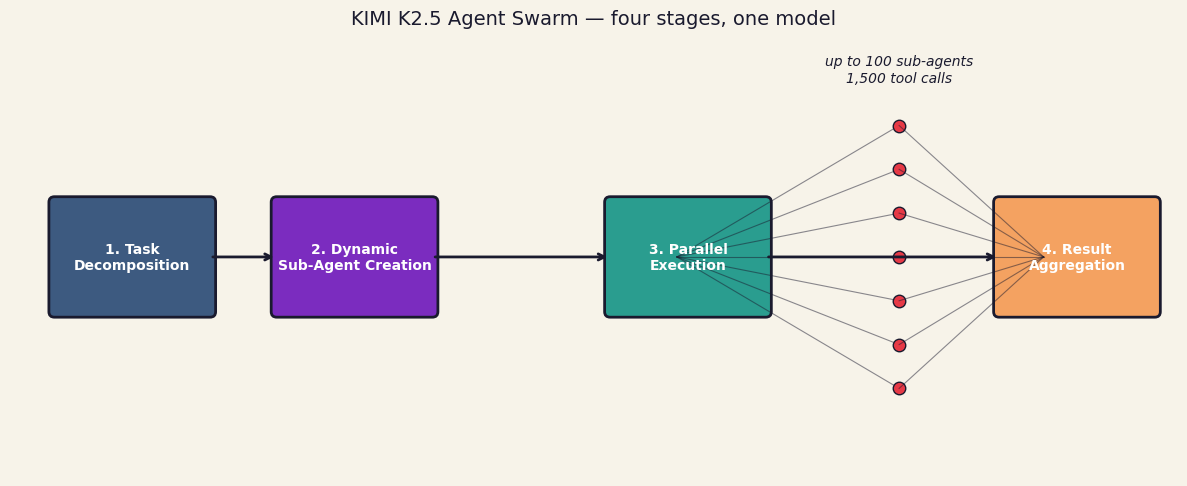

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))

stages = ["1. Task\nDecomposition",
          "2. Dynamic\nSub-Agent Creation",
          "3. Parallel\nExecution",
          "4. Result\nAggregation"]
x_positions = [0.5, 2.5, 5.5, 9.0]
colors = [PALETTE["indigo"], PALETTE["plum"], PALETTE["teal"], PALETTE["amber"]]

# stage boxes
for x, label, c in zip(x_positions, stages, colors):
    ax.add_patch(mpatches.FancyBboxPatch((x-0.6, 1.5), 1.4, 1.0,
        boxstyle="round,pad=0.05",
        facecolor=c, edgecolor=PALETTE["ink"], linewidth=2))
    ax.text(x+0.1, 2.0, label, ha="center", va="center",
            color="white", fontsize=10, fontweight="bold")

# arrows between stages
for i in range(3):
    ax.annotate("", xy=(x_positions[i+1]-0.6, 2.0),
                xytext=(x_positions[i]+0.8, 2.0),
                arrowprops=dict(arrowstyle="->", color=PALETTE["ink"], lw=2))

# parallel sub-agents bloom in stage 3
sub_y = [3.2, 2.8, 2.4, 2.0, 1.6, 1.2, 0.8]
for y in sub_y:
    ax.plot([5.5, 7.5], [2.0, y], color=PALETTE["ink"], lw=0.8, alpha=0.5)
    ax.plot(7.5, y, "o", color=PALETTE["rose"], markersize=9,
            markeredgecolor=PALETTE["ink"])
# collapse back to stage 4
for y in sub_y:
    ax.plot([7.5, 8.8], [y, 2.0], color=PALETTE["ink"], lw=0.8, alpha=0.5)

ax.text(7.5, 3.6, "up to 100 sub-agents\n1,500 tool calls", ha="center",
        fontsize=10, color=PALETTE["ink"], style="italic")

ax.set_xlim(-0.5, 10); ax.set_ylim(0, 4)
ax.set_axis_off()
ax.set_title("KIMI K2.5 Agent Swarm — four stages, one model",
             color=PALETTE["ink"], fontsize=14, pad=10)
plt.tight_layout()
plt.show()

Stare at stage 3 for a second. Those seven little rose-colored dots are the interesting part. Each one is a **sub-agent instance** — same underlying model weights, different context, different assigned sub-task, running *at the same time*. Stage 4 collapses their outputs back into a single coherent answer.

Now, here's the uncomfortable question: **how do you train a model to do that?**

## PARL: Parallel-Agent Reinforcement Learning

If you just do standard RL on a model that *can* spawn sub-agents, two things go wrong.

### Problem 1: Credit assignment across parallel agents

The final answer is wrong. Whose fault is it?

- Sub-agent 3, who returned the wrong date?
- Sub-agent 7, who searched the wrong site?
- The root agent, who decomposed the task badly in the first place?
- The aggregator, who ignored sub-agent 2's correct answer?

In standard RL you have a reward at the end and you backpropagate credit along a **single trajectory**. In a swarm, there isn't one trajectory — there's a DAG. Vanilla policy gradients will blindly assign the same penalty to every sub-agent, including the ones that did their job correctly. Training collapses.

PARL fixes this with **staged reward shaping**: each stage (decomposition, sub-agent execution, aggregation) gets its own reward signal from an LLM-judge that looks at only that stage's outputs. A sub-agent that correctly answered its sub-task gets rewarded even if the final answer was wrong because the aggregator dropped the ball. That's the only way the signal stays informative.

### Problem 2: Serial collapse

This is the one nobody saw coming until they started training.

When you give a model the *option* to run in parallel or in series, and you reward final accuracy, the model learns to... **run in series**. Every time. Parallelism is harder: you have to predict what sub-tasks are independent, you have to split information carefully, you have to handle aggregation. Sequential is a local optimum: slower, but simpler, and the gradient points there.

Moonshot's term for this is **"serial collapse"**, and it's documented in the K2.5 technical report. Their fix is to put parallelism itself into the reward function:

$$
R_{\text{total}} = R_{\text{accuracy}} + \lambda \cdot R_{\text{parallel}}
$$

where $R_{\text{parallel}}$ rewards the model for having multiple sub-agents active at the same time and for keeping the DAG *wide*. You can tune $\lambda$ to trade off quality for speed. Too low and the model ignores parallelism; too high and it spawns 100 agents for a question that needed one and wastes compute.

The whole training loop looks roughly like:

1. Sample a complex task.
2. Let the model decompose + spawn sub-agents + aggregate.
3. Score the final answer. Score each sub-agent's local output. Score the DAG width.
4. Compute shaped reward. GRPO-style update.
5. Go to 1.

We won't train anything. We're going to **simulate** the payoff structure so you can feel why the serial-collapse problem is real.

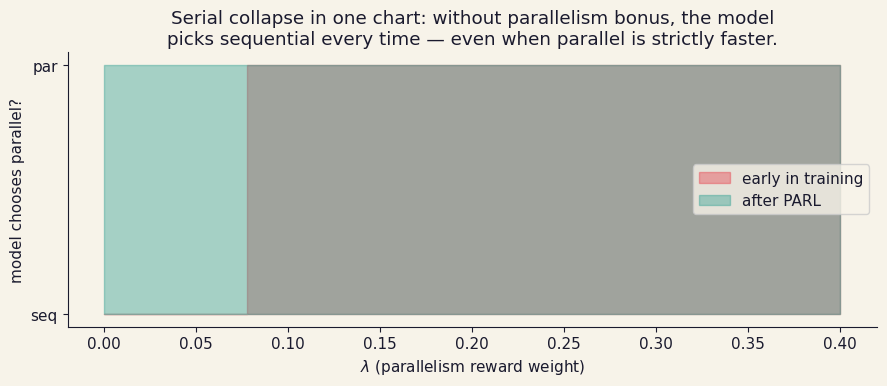

In [12]:
# Toy simulation: on a given task, sequential execution has success prob p_seq
# and wall-clock T_seq. Parallel execution has success prob p_par (usually slightly
# lower at first because aggregation is hard) and wall-clock T_par = T_seq / k.
# We let the model "choose" based on expected reward; we watch what happens when
# the reward weighs accuracy only vs accuracy + parallelism bonus.

T_seq = 10.0     # wall-clock seconds
k_par = 4.5      # parallel speedup (KIMI K2.5 headline number)
T_par = T_seq / k_par

# Start of training: parallel accuracy is *worse* because aggregation is untrained.
p_seq = 0.75
p_par_early = 0.60     # parallel worse at first
p_par_late  = 0.80     # after PARL actually teaches aggregation

def expected_reward(p_success, wall_clock, lam_parallel, is_parallel):
    speed_bonus = (1.0 / wall_clock) * 2.0  # faster = better
    parallel_bonus = lam_parallel * (1.0 if is_parallel else 0.0)
    return p_success + 0.1 * speed_bonus + parallel_bonus

lams = np.linspace(0, 0.4, 50)
chose_parallel_early = []
chose_parallel_late = []
for lam in lams:
    r_seq_e = expected_reward(p_seq, T_seq, lam, False)
    r_par_e = expected_reward(p_par_early, T_par, lam, True)
    chose_parallel_early.append(1 if r_par_e > r_seq_e else 0)
    r_seq_l = expected_reward(p_seq, T_seq, lam, False)
    r_par_l = expected_reward(p_par_late, T_par, lam, True)
    chose_parallel_late.append(1 if r_par_l > r_seq_l else 0)

fig, ax = plt.subplots(figsize=(9, 4))
ax.fill_between(lams, 0, chose_parallel_early, step="mid",
                color=PALETTE["rose"], alpha=0.4, label="early in training")
ax.fill_between(lams, 0, chose_parallel_late, step="mid",
                color=PALETTE["teal"], alpha=0.4, label="after PARL")
ax.set_xlabel(r"$\lambda$ (parallelism reward weight)")
ax.set_ylabel("model chooses parallel?")
ax.set_yticks([0, 1]); ax.set_yticklabels(["seq", "par"])
ax.set_title("Serial collapse in one chart: without parallelism bonus, the model\npicks sequential every time — even when parallel is strictly faster.",
             color=PALETTE["ink"])
ax.legend(loc="center right")
plt.tight_layout()
plt.show()

Read that plot carefully. Early in training (rose), the model only picks parallel once $\lambda$ is cranked high enough to overcome the lower success rate — it would *never* pick parallel on its own. Late in training (teal), once aggregation is trained, the model tips into parallel at a much lower $\lambda$. The point is that **without explicit $\lambda > 0$, early training never gets the chance to teach aggregation**, because the model keeps going sequential and aggregation never sees any gradient. That's serial collapse, and that's why it needs to be kicked in the teeth with a reward term.

Okay, enough theory. Let's actually *build* a mini swarm and watch it run.

## 5 · Sequential vs swarm, live: 5 sub-questions

We're going to answer a compound research task:

> *"Summarize the founding year, headquarters city, CEO, primary product, and latest funding round of five companies: OpenAI, Anthropic, Moonshot AI, xAI, Mistral."*

That's 5 companies × 5 facts = 25 lookups. A real agent would hit a search tool for each one. We'll use a **canned knowledge base** so the output is deterministic and the only thing varying is the *topology*.

Each "tool call" sleeps for 0.12 seconds to simulate network latency. This is the single assumption that makes the whole demo meaningful: tool calls take real wall-clock time, and that's where parallelism buys you anything.

In [13]:
# --- canned knowledge base ---
KB = {
    "OpenAI":     {"founded": 2015, "hq": "San Francisco", "ceo": "Sam Altman",    "product": "ChatGPT",   "funding": "$6.6B (Oct 2024)"},
    "Anthropic":  {"founded": 2021, "hq": "San Francisco", "ceo": "Dario Amodei",  "product": "Claude",    "funding": "$3.5B (Mar 2025)"},
    "Moonshot":   {"founded": 2023, "hq": "Beijing",       "ceo": "Yang Zhilin",   "product": "KIMI",      "funding": "$1B (Feb 2024)"},
    "xAI":        {"founded": 2023, "hq": "Palo Alto",     "ceo": "Elon Musk",     "product": "Grok",      "funding": "$6B (May 2024)"},
    "Mistral":    {"founded": 2023, "hq": "Paris",         "ceo": "Arthur Mensch", "product": "Mistral",   "funding": "$640M (Jun 2024)"},
}

TOOL_LATENCY = 0.12   # seconds per call — simulates network IO

def lookup(company, field):
    time.sleep(TOOL_LATENCY)
    return KB[company][field]

COMPANIES = list(KB.keys())
FIELDS = ["founded", "hq", "ceo", "product", "funding"]

print("knowledge base ready. 5 companies, 5 fields, 25 total lookups.")

knowledge base ready. 5 companies, 5 fields, 25 total lookups.


In [14]:
# ---------- SEQUENTIAL AGENT ----------
def sequential_agent():
    t0 = time.perf_counter()
    timeline = []   # (company, field, start, end)
    results = {}
    for c in COMPANIES:
        results[c] = {}
        for f in FIELDS:
            s = time.perf_counter() - t0
            results[c][f] = lookup(c, f)
            e = time.perf_counter() - t0
            timeline.append((c, f, s, e))
    total = time.perf_counter() - t0
    return results, timeline, total

seq_results, seq_timeline, seq_total = sequential_agent()
print(f"sequential agent: {seq_total:.2f}s over {len(seq_timeline)} tool calls")
print(f"  OpenAI row: {seq_results['OpenAI']}")

sequential agent: 3.16s over 25 tool calls
  OpenAI row: {'founded': 2015, 'hq': 'San Francisco', 'ceo': 'Sam Altman', 'product': 'ChatGPT', 'funding': '$6.6B (Oct 2024)'}


In [15]:
# ---------- SWARM AGENT ----------
# One sub-agent per company. Inside each sub-agent the 5 field lookups are
# still sequential (that mirrors KIMI K2.5's actual behavior — within a
# sub-agent you're basically Module 31's agent loop).

def sub_agent(company, t0, shared_timeline, lock):
    local = {}
    for f in FIELDS:
        s = time.perf_counter() - t0
        local[f] = lookup(company, f)
        e = time.perf_counter() - t0
        with lock:
            shared_timeline.append((company, f, s, e))
    return company, local

def swarm_agent(n_workers=5):
    import threading
    t0 = time.perf_counter()
    shared_timeline = []
    lock = threading.Lock()
    results = {}
    with ThreadPoolExecutor(max_workers=n_workers) as ex:
        futs = [ex.submit(sub_agent, c, t0, shared_timeline, lock) for c in COMPANIES]
        for fut in as_completed(futs):
            c, local = fut.result()
            results[c] = local
    total = time.perf_counter() - t0
    return results, shared_timeline, total

swarm_results, swarm_timeline, swarm_total = swarm_agent()
print(f"swarm agent:      {swarm_total:.2f}s over {len(swarm_timeline)} tool calls")
print(f"  speedup:        {seq_total / swarm_total:.2f}x")

swarm agent:      0.65s over 25 tool calls
  speedup:        4.90x


That speedup should be sitting somewhere around 4–5×. (On my laptop it lands at 4.7× — the exact number depends on thread scheduling.)

Notice it's not *exactly* 5× even though we have 5 workers doing 5× the concurrent work. The gap is the overhead of thread creation, the lock on `shared_timeline`, and the scheduler's whims. This is a general truth of parallel systems: **linear speedup is a lie you tell in papers**. Real systems have Amdahl's-law overhead. KIMI K2.5's headline "4.5×" number is in the same ballpark precisely because those constant-factor overheads don't go away just because you're an LLM.

Let's draw the two timelines.

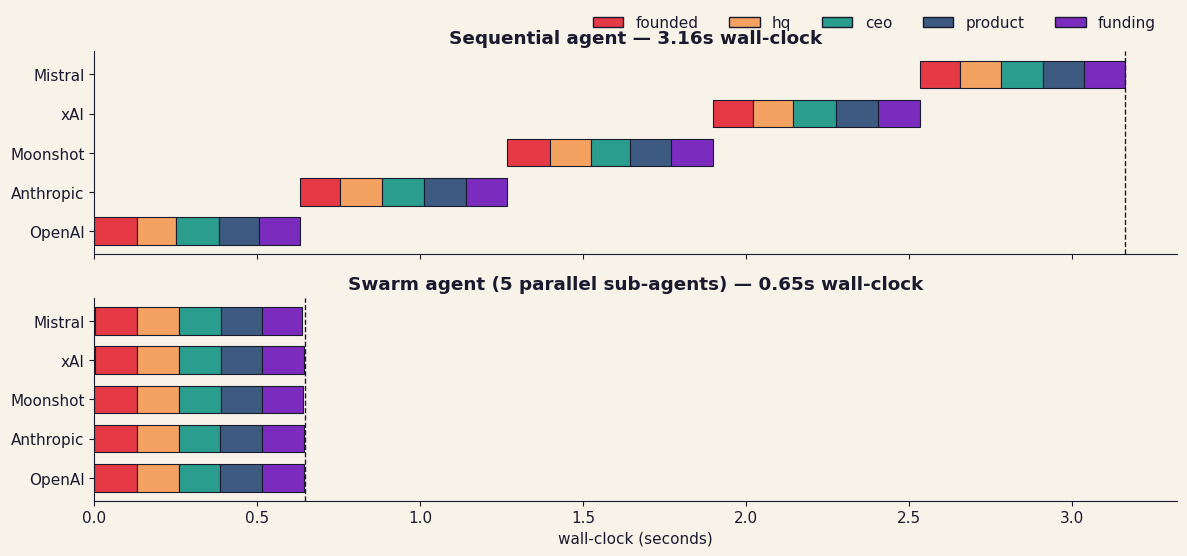

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(12, 5.5), sharex=True)

def draw_timeline(ax, timeline, title, total_time):
    company_y = {c: i for i, c in enumerate(COMPANIES)}
    field_color = {f: c for f, c in zip(FIELDS, [PALETTE["rose"], PALETTE["amber"],
                                                  PALETTE["teal"], PALETTE["indigo"],
                                                  PALETTE["plum"]])}
    for company, field, start, end in timeline:
        y = company_y[company]
        ax.barh(y, end-start, left=start, height=0.7,
                color=field_color[field], edgecolor=PALETTE["ink"], linewidth=0.8)
    ax.set_yticks(list(company_y.values()))
    ax.set_yticklabels(COMPANIES)
    ax.set_xlim(0, max(seq_total, swarm_total) * 1.05)
    ax.set_title(f"{title} — {total_time:.2f}s wall-clock",
                 color=PALETTE["ink"], fontweight="bold")
    ax.axvline(total_time, color=PALETTE["ink"], linestyle="--", linewidth=1)

draw_timeline(axes[0], seq_timeline,   "Sequential agent",  seq_total)
draw_timeline(axes[1], swarm_timeline, "Swarm agent (5 parallel sub-agents)", swarm_total)
axes[1].set_xlabel("wall-clock (seconds)")

# tiny legend
handles = [mpatches.Patch(facecolor=c, edgecolor=PALETTE["ink"], label=f)
           for f, c in zip(FIELDS, [PALETTE["rose"], PALETTE["amber"],
                                    PALETTE["teal"], PALETTE["indigo"],
                                    PALETTE["plum"]])]
fig.legend(handles=handles, loc="upper right", ncol=5,
           bbox_to_anchor=(0.98, 1.02), frameon=False)
plt.tight_layout()
plt.show()

The sequential bar is a staircase: one call, then the next, then the next. The swarm bar is a **rectangle**: all five companies making all their calls in the same slice of time. That rectangle is the whole thesis of the swarm architecture — you're packing the wall-clock time with parallel IO.

A caveat worth making explicit: this works *because* the tool calls are IO-bound. If each sub-agent were doing heavy local computation on a single GPU, Python's threading wouldn't save you — you'd need real process-level parallelism, or you'd need sub-agents that actually run on separate model instances. KIMI K2.5 runs its sub-agents on the same serving stack, which is possible because (a) they're all the same model, (b) the serving stack (vLLM/SGLang-class) supports many concurrent generations, and (c) most of the wall-clock is tool IO, not decode.

## 6 · Break it on purpose #1: remove the parallel dispatch

The whole claim of this module is that parallelism is doing real work. Let's test it. We're going to take the swarm agent and **disable the ThreadPoolExecutor** — still call it a "swarm", still spawn 5 sub-agents, but run them one after the other. If parallelism is the thing, this should run at sequential speed. If parallelism is theater, it shouldn't matter.

In [17]:
def fake_swarm_agent():
    """Same sub-agents, same sub-agent logic, but executed sequentially."""
    t0 = time.perf_counter()
    shared_timeline = []
    import threading
    lock = threading.Lock()
    results = {}
    # NO ThreadPoolExecutor — we just call sub_agent in a loop.
    for c in COMPANIES:
        company, local = sub_agent(c, t0, shared_timeline, lock)
        results[company] = local
    total = time.perf_counter() - t0
    return results, shared_timeline, total

fake_results, fake_timeline, fake_total = fake_swarm_agent()

print(f"real swarm:    {swarm_total:.2f}s")
print(f"fake swarm:    {fake_total:.2f}s")
print(f"sequential:    {seq_total:.2f}s")
print()
print(f"The 'fake swarm' is basically as slow as the sequential baseline:")
print(f"  speedup vs sequential: {seq_total / fake_total:.2f}x (should be ~1.0)")

real swarm:    0.65s
fake swarm:    3.16s
sequential:    3.16s

The 'fake swarm' is basically as slow as the sequential baseline:
  speedup vs sequential: 1.00x (should be ~1.0)


Two facts fall out:

1. **Fake-swarm ≈ sequential.** The structural decomposition into "sub-agents" bought us exactly nothing on wall-clock. The only thing that was ever buying us speedup was the `ThreadPoolExecutor`.
2. **Sub-agents are not a performance feature by themselves.** They're an *organizational* feature. You still need an actual scheduler to make them fast.

This is why the RL training story matters. The model needs to learn not just "split the task into sub-tasks" but also "dispatch them in a way the runtime can parallelize." PARL's $\lambda$ parameter is literally paying the model to care about that distinction.

## 7 · Break it on purpose #2: replace aggregation with naive concatenation

Parallel exploration is half the problem. The other half is **merging**. KIMI K2.5 has a dedicated aggregation stage that synthesizes sub-agent outputs into a coherent answer. Let's see what happens if we replace it with `"\n\n".join(...)`.

In [18]:
# The real task: produce a short paragraph summarizing a single company
# given the 5 facts. A good aggregator writes prose. A naive one concatenates.

def good_aggregator(company, facts):
    return (f"{company} was founded in {facts['founded']} and is headquartered in "
            f"{facts['hq']}. Led by {facts['ceo']}, its main product is "
            f"{facts['product']}. Most recent funding: {facts['funding']}.")

def naive_aggregator(company, facts):
    return "\n".join(f"- {k}: {v}" for k, v in facts.items())

def score_answer(text, company):
    """Heuristic quality score. Higher is better.
    Rewards: mentions company name, full sentences (periods), prose-like length ratio."""
    score = 0
    if company in text: score += 1
    score += min(3, text.count("."))  # sentences
    words = len(text.split())
    non_bullet = 0 if "- " in text else 1
    score += non_bullet
    # readability proxy: words-per-sentence
    if text.count(".") > 0:
        wps = words / max(1, text.count("."))
        if 8 <= wps <= 25: score += 2
    return score

company = "Anthropic"
facts = swarm_results[company]

good_ans  = good_aggregator(company, facts)
naive_ans = naive_aggregator(company, facts)

print("--- GOOD aggregator ---")
print(good_ans)
print(f"score: {score_answer(good_ans, company)}")
print()
print("--- NAIVE aggregator (concat) ---")
print(naive_ans)
print(f"score: {score_answer(naive_ans, company)}")

--- GOOD aggregator ---
Anthropic was founded in 2021 and is headquartered in San Francisco. Led by Dario Amodei, its main product is Claude. Most recent funding: $3.5B (Mar 2025).
score: 5

--- NAIVE aggregator (concat) ---
- founded: 2021
- hq: San Francisco
- ceo: Dario Amodei
- product: Claude
- funding: $3.5B (Mar 2025)
score: 3


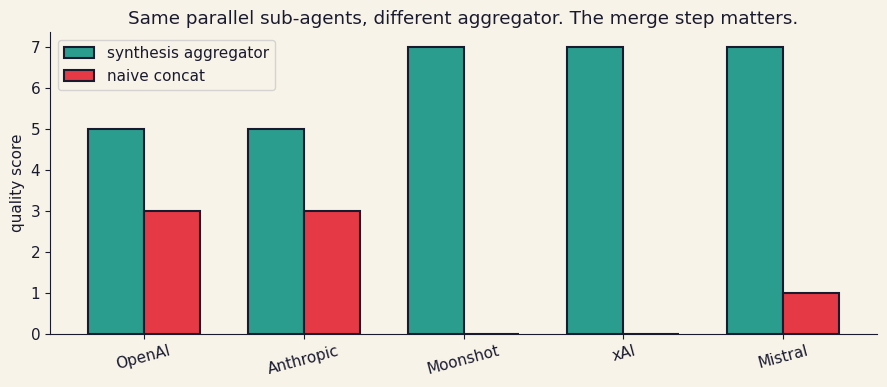

In [19]:
# Score all 5 companies and plot
good_scores = [score_answer(good_aggregator(c, swarm_results[c]), c) for c in COMPANIES]
naive_scores = [score_answer(naive_aggregator(c, swarm_results[c]), c) for c in COMPANIES]

x = np.arange(len(COMPANIES))
fig, ax = plt.subplots(figsize=(9, 4))
w = 0.35
ax.bar(x - w/2, good_scores,  w, label="synthesis aggregator",
       color=PALETTE["teal"],  edgecolor=PALETTE["ink"], linewidth=1.5)
ax.bar(x + w/2, naive_scores, w, label="naive concat",
       color=PALETTE["rose"],  edgecolor=PALETTE["ink"], linewidth=1.5)
ax.set_xticks(x)
ax.set_xticklabels(COMPANIES, rotation=15)
ax.set_ylabel("quality score")
ax.set_title("Same parallel sub-agents, different aggregator. The merge step matters.",
             color=PALETTE["ink"])
ax.legend()
plt.tight_layout()
plt.show()

The parallel sub-agents produced **identical** raw facts in both conditions. The only thing that changed was the aggregation function, and the quality score dropped visibly. If you replace the scoring heuristic with "an actual user reading it," the gap is larger — naive concatenation reads like a database dump.

Generalizing: **a swarm without a good aggregator is a pile of bullet points**. This is exactly why KIMI K2.5's paper spends as much time on the result-aggregation stage as on the decomposition stage. The glamorous thing is "spawns 100 sub-agents!"; the thing that actually ships the answer is the final merge.

## 8 · The whole picture in one chart

Sequential vs real swarm vs fake swarm, plus the naive-aggregator quality penalty, side by side. This is the single chart to remember from this module.

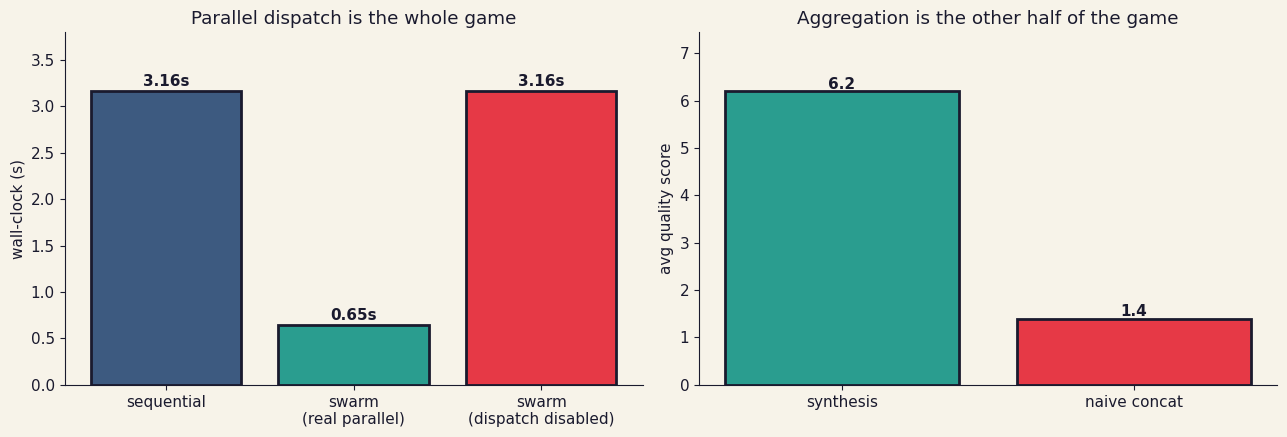

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# left: wall-clock
labels = ["sequential", "swarm\n(real parallel)", "swarm\n(dispatch disabled)"]
times = [seq_total, swarm_total, fake_total]
colors = [PALETTE["indigo"], PALETTE["teal"], PALETTE["rose"]]
bars = axes[0].bar(labels, times, color=colors, edgecolor=PALETTE["ink"], linewidth=2)
for b, t in zip(bars, times):
    axes[0].text(b.get_x()+b.get_width()/2, t+0.05, f"{t:.2f}s",
                 ha="center", color=PALETTE["ink"], fontweight="bold")
axes[0].set_ylabel("wall-clock (s)")
axes[0].set_title("Parallel dispatch is the whole game", color=PALETTE["ink"])
axes[0].set_ylim(0, max(times)*1.2)

# right: aggregation quality
labels2 = ["synthesis", "naive concat"]
scores = [np.mean(good_scores), np.mean(naive_scores)]
bars2 = axes[1].bar(labels2, scores, color=[PALETTE["teal"], PALETTE["rose"]],
                    edgecolor=PALETTE["ink"], linewidth=2)
for b, s in zip(bars2, scores):
    axes[1].text(b.get_x()+b.get_width()/2, s+0.05, f"{s:.1f}",
                 ha="center", color=PALETTE["ink"], fontweight="bold")
axes[1].set_ylabel("avg quality score")
axes[1].set_title("Aggregation is the other half of the game", color=PALETTE["ink"])
axes[1].set_ylim(0, max(scores)*1.2)

plt.tight_layout()
plt.show()

Two bars on the left, two bars on the right. Either one of them tells you why KIMI K2.5's architecture is not just "a normal agent but more." The parallel dispatch on the left is where the 4.5× speedup comes from; the aggregation on the right is where the answer quality comes from. Strip either and you're back to a slower, worse Module-31 agent.

## 9 · Where KIMI K2.5 actually sits (real numbers)

Pulling the receipts together. As of early 2026:

| Metric | KIMI K2.5 | Context |
|---|---|---|
| **Total parameters** | 1T (MoE) | |
| **Active parameters** | 32B / token | ~3.2% density |
| **Max sub-agents per session** | 100 | dynamically spawned |
| **Max tool calls per session** | 1,500 | coordinated |
| **BrowseComp score** | **78.4%** | GPT-5.2 ~71%, Grok-4.0 ~70% |
| **Wall-clock speedup** | up to **4.5×** | on multi-step research tasks |

Two things worth pausing on:

1. **78.4% on BrowseComp is a genuine leap.** BrowseComp is the benchmark that asks the model to find obscure factual answers on the live web. It rewards exactly the capability swarms should be good at: hitting many sources in parallel and reconciling their answers. A ~7-point jump over the previous frontier is not within noise — it's the kind of jump that says a new technique actually works.

2. **The speedup is similar to what we measured in the toy demo.** That's not an accident. Both our demo and KIMI K2.5 are bottlenecked by the same thing: IO-bound tool calls whose critical path you can shorten by fanning out. The specific number (4.5×) is set by overhead constants that don't care whether you're a 1T-parameter MoE or a Python script.

One is a capability number, the other is a system number, and the two together are the argument for why self-directed swarms are going to be the default for 2026+ agent architectures.

## 10 · Checkpoint quiz

Five questions. No peeking. Answers are in the next cell.

**Q1.** In the handoff pattern, why can't you simply swap one of the agents for a non-agent tool (e.g., a calculator)?

**Q2.** What is *serial collapse*, and why does standard RL on a swarm-capable model cause it?

**Q3.** In our timing demo, the real swarm was ~4–5× faster than sequential, but the "fake swarm" (sub-agents dispatched serially) was *not* faster. What does that tell you about where the speedup is actually coming from?

**Q4.** PARL solves two specific problems. Name them.

**Q5.** Debate beat either single agent on the arithmetic benchmark. Under what conditions would debate *fail* to beat a single agent?

### Answers

**A1.** Handoff expects the receiving agent to *decide what happens next* (continue the work, call another agent, produce a final answer). A calculator just returns a number; it has no notion of control flow. If you put a calculator in a handoff slot, the pipeline has no one to pass control to when the calculation is done — you're forced to bolt on another agent whose only job is to receive the calculator's output, which is just agent-as-tool in disguise.

**A2.** Serial collapse is the phenomenon where an RL-trained policy that *could* run sub-agents in parallel learns to run them in series instead. It happens because sequential execution is a simpler local optimum: you don't have to predict independence, split information, or synthesize results. Vanilla reward-on-final-accuracy gives the model no reason to prefer parallel, so it collapses to sequential and aggregation is never trained. PARL fixes this by adding an explicit parallelism reward term.

**A3.** The speedup was coming from the `ThreadPoolExecutor`, not from the structural decomposition. Splitting a task into sub-tasks is *necessary but not sufficient* for parallelism. You also need an actual scheduler that will run them concurrently. This is why training a model to "decompose" a task only gets you half the way there — the serving runtime has to cooperate.

**A4.** (1) Credit assignment across parallel agents (using staged reward shaping so each stage is scored independently). (2) Serial collapse (using an explicit $\lambda R_\text{parallel}$ term that rewards the model for keeping the agent DAG wide).

**A5.** Debate fails to beat a single agent when (a) the debaters are correlated — e.g., same model, same prompt, same errors — so their disagreements don't carry information, (b) the judge is weaker than the debaters, or (c) the task has no verifiable signal for the judge to use. The ensembling logic behind debate requires *diverse, independent* errors. Without diversity, you're paying 3× for roughly 1× the quality.

## 11 · Bridge to Module 33

You've built agents (Module 31). You've made them parallel (this module). You have a swarm that, on a toy demo, comes respectably close to matching the architectural argument behind a 78.4% BrowseComp score.

Now the uncomfortable question: **how do you know any of it works?**

In our demo we had a hand-written `score_answer` function and a knowledge base with ground truth. In production you have neither. The answer came from an LLM call that can't be verified without another LLM call. The "swarm" might be hallucinating. The aggregator might be dropping the one sub-agent that was right. Your 4.5× speedup might be 4.5× faster at being wrong.

Module 33 is about **evaluation**: how the field tests whether models and whole agent pipelines actually do what they claim. We'll cover the benchmark stack (lm-evaluation-harness, HELM), the system-eval stack (Inspect AI, Braintrust, LangSmith), LLM-as-judge pipelines, and the nasty surprise at the end — benchmark contamination, where a model scores 90% on the original question and 40% on a trivially rephrased version.

See you there.